# EU AI Act Compliance Classifier
## Notebook 02 — Preprocessing & EU AI Act Labeling

**Author:** Jayesh Ranghera  
**Project:** EU AI Act Compliance Classifier  
**Purpose:** Clean the merged dataset, apply EU AI Act risk labels using a rule-based keyword classifier, and prepare the final labeled dataset for model training.

---

## 1. Import Libraries

In [1]:
import os
os.chdir('..')
print(os.getcwd())
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 20)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print("Libraries loaded successfully.")

/Users/jayeshranghera/Documents/Projects/eu-ai-act-compliance 
Libraries loaded successfully.


## 2. Load Dataset

In [5]:
#Load merged data from Notebook1
df = pd.read_csv('data/processed/merged_raw.csv')
seed_df = pd.read_csv('data/processed/seed_labeled.csv')

print(df.columns.to_list())
print(f"Merged dataset: {df.shape[0]} Rows, {df.shape[1]} Columns")
print(f"Seed dataset: {seed_df.shape[0]} Rows, {seed_df.shape[1]} Columns")
df.head(3)

['incident_id', 'title', 'description', 'Alleged deployer of AI system', 'Alleged developer of AI system', 'Alleged harmed or nearly harmed parties', 'date', 'report_description', 'text', 'ai_system_description']
Merged dataset: 514 Rows, 10 Columns
Seed dataset: 20 Rows, 5 Columns


,incident_id,title,description,Alleged deployer of AI system,Alleged developer of AI system,Alleged harmed or nearly harmed parties,date,report_description,text,ai_system_description
0,23,Las Vegas Self-Driving Bus Involved in Accident,A self-driving public shuttle by Keolis North America and Navya was involved in a collision with a human-driven deli...,"[""navya"",""keolis-north-america""]","[""navya"",""keolis-north-america""]","[""navya"",""keolis-north-america"",""bus-passengers""]",2017-11-08,NaN,NaN,A self-driving public shuttle by Keolis North America and Navya was involved in a collision with a human-driven deli...
1,4,Uber AV Killed Pedestrian in Arizona,"An Uber autonomous vehicle (AV) in autonomous mode struck and killed a pedestrian in Tempe, Arizona.","[""uber""]","[""uber""]","[""elaine-herzberg"",""pedestrians""]",2018-03-18,NaN,NaN,"An Uber autonomous vehicle (AV) in autonomous mode struck and killed a pedestrian in Tempe, Arizona."
2,1,Google’s YouTube Kids App Presents Inappropriate Content,YouTube’s content filtering and recommendation algorithms exposed children to disturbing and inappropriate videos.,"[""youtube""]","[""youtube""]","[""children""]",2015-05-19,NaN,NaN,YouTube’s content filtering and recommendation algorithms exposed children to disturbing and inappropriate videos.


## 3. Text Preprocessing

In [6]:
def clean_text(text):
    """Clean and normalize text for classification."""
    if pd.isna(text):
        return ""
    # Lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters — keep letters, numbers, spaces
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
df['clean_description'] = df['ai_system_description'].apply(clean_text)
df['clean_title'] = df['title'].apply(clean_text)

# Combined text field — title + description for better classification
df['combined_text'] = df['clean_title'] + ' ' + df['clean_description']

print("Text cleaning complete.")
print("\nSample cleaned text:")
for i, row in df[['title', 'combined_text']].head(3).iterrows():
    print(f"\nOriginal : {row['title']}")
    print(f"Cleaned  : {row['combined_text'][:120]}")

Text cleaning complete.

Sample cleaned text:

Original : Las Vegas Self-Driving Bus Involved in Accident
Cleaned  : las vegas self driving bus involved in accident a self driving public shuttle by keolis north america and navya was invo

Original : Uber AV Killed Pedestrian in Arizona
Cleaned  : uber av killed pedestrian in arizona an uber autonomous vehicle av in autonomous mode struck and killed a pedestrian in 

Original : Google’s YouTube Kids App Presents Inappropriate Content
Cleaned  : google s youtube kids app presents inappropriate content youtube s content filtering and recommendation algorithms expos


We clean the `ai_system_description` field before applying classification rules.

Steps:
- Lowercase all text
- Remove special characters and extra whitespace
- Strip punctuation
- Keep meaningful words only

## 4. EU AI Act Rule-Based Classifier

In [7]:
# EU AI ACT KEYWORD RULES
# Based on Annex I, Annex III, and Article 52

PROHIBITED_KEYWORDS = [
    # Social scoring
    'social scor', 'citizen scor', 'social credit', 'behavior scor',
    # Subliminal manipulation
    'subliminal', 'manipulat', 'deepfake', 'synthetic media', 'fake video',
    'disinformation', 'misinformation campaign',
    # Real-time biometric surveillance in public
    'real.time biometric', 'mass surveillance', 'real time facial recognition public',
    # Exploit vulnerabilities
    'exploit vulnerab', 'exploit children', 'exploit elderly',
    # Emotion recognition workplace/education
    'emotion recogni', 'emotion detect'
]

HIGH_RISK_KEYWORDS = {
    # Annex III - Category 1: Biometric identification
    'Annex III - Category 1 (Biometric)': [
        'facial recognition', 'biometric', 'fingerprint', 'iris recogni',
        'face recogni', 'identity verif', 'face detect', 'person identif'
    ],
    # Annex III - Category 2: Critical infrastructure
    'Annex III - Category 2 (Critical Infrastructure)': [
        'autonomous vehicle', 'self.driving', 'autopilot', 'power grid',
        'electricity grid', 'water system', 'traffic control', 'railway',
        'aviation', 'aircraft', 'drone military', 'infrastructure',
        'robot kill', 'warehouse robot', 'industrial robot'
    ],
    # Annex III - Category 3: Education
    'Annex III - Category 3 (Education)': [
        'student', 'education', 'school', 'university', 'admission',
        'academic', 'teacher evaluat', 'exam', 'grading', 'learning platform'
    ],
    # Annex III - Category 4: Employment
    'Annex III - Category 4 (Employment)': [
        'hiring', 'recruitment', 'resume', 'job applicant', 'employ',
        'workforce', 'performance monitor', 'worker', 'scheduling algorithm',
        'salary', 'promotion', 'termination'
    ],
    # Annex III - Category 5: Essential services
    'Annex III - Category 5 (Essential Services)': [
        'credit scor', 'loan', 'insurance', 'bank', 'financial',
        'healthcare', 'medical', 'surgery', 'hospital', 'patient',
        'diagnosis', 'drug', 'clinical', 'health', 'robotic surgery'
    ],
    # Annex III - Category 6: Law enforcement
    'Annex III - Category 6 (Law Enforcement)': [
        'law enforcement', 'police', 'crime predict', 'criminal',
        'recidivism', 'arrest', 'sentencing', 'court', 'justice',
        'profiling', 'risk assess', 'northpointe', 'compas'
    ],
    # Annex III - Category 7: Migration
    'Annex III - Category 7 (Migration)': [
        'migration', 'asylum', 'border control', 'visa', 'refugee',
        'immigration'
    ],
    # Annex III - Category 8: Democracy & justice
    'Annex III - Category 8 (Democracy)': [
        'election', 'voting', 'democratic', 'political', 'propaganda',
        'content moderat', 'censorship', 'platform moderat'
    ]
}

LIMITED_RISK_KEYWORDS = [
    'chatbot', 'virtual assistant', 'recommendation', 'content filter',
    'spam filter', 'ad target', 'advertisement', 'search result',
    'image label', 'sentiment analys', 'language model', 'translation'
]

print("EU AI Act classification rules defined.")
print(f"  Prohibited keywords  : {len(PROHIBITED_KEYWORDS)}")
print(f"  High Risk categories : {len(HIGH_RISK_KEYWORDS)}")
print(f"  Limited Risk keywords: {len(LIMITED_RISK_KEYWORDS)}")

EU AI Act classification rules defined.
  Prohibited keywords  : 19
  High Risk categories : 8
  Limited Risk keywords: 12


In [8]:
def classify_risk_level(text):
    """Classify AI system description into EU AI Act risk levels."""
    text = str(text).lower()
    
    # Step 1 — Check Prohibited
    for keyword in PROHIBITED_KEYWORDS:
        if re.search(keyword, text):
            return 'Prohibited', 'Annex I', f'Matches prohibited keyword: "{keyword}"'
    
    # Step 2 — Check High Risk (check each category)
    for category, keywords in HIGH_RISK_KEYWORDS.items():
        for keyword in keywords:
            if re.search(keyword, text):
                return 'High Risk', category, f'Matches high risk keyword: "{keyword}"'
    
    # Step 3 — Check Limited Risk
    for keyword in LIMITED_RISK_KEYWORDS:
        if re.search(keyword, text):
            return 'Limited Risk', 'Article 52', f'Matches limited risk keyword: "{keyword}"'
    
    # Step 4 — Default: Minimal Risk
    return 'Minimal Risk', 'Not applicable', 'No high-risk or prohibited patterns detected'


# Apply classifier to all incidents
results = df['combined_text'].apply(classify_risk_level)
df['risk_level'] = results.apply(lambda x: x[0])
df['annex_reference'] = results.apply(lambda x: x[1])
df['classification_reason'] = results.apply(lambda x: x[2])

print("Classification complete.")
print(f"\nRisk Level Distribution:")
print(df['risk_level'].value_counts())

Classification complete.

Risk Level Distribution:
risk_level
High Risk       256
Minimal Risk    190
Limited Risk     38
Prohibited       30
Name: count, dtype: int64


Since the AIID dataset has no EU AI Act labels, we build a **rule-based keyword classifier** grounded in:

- **Annex I** — Prohibited AI systems
- **Annex III** — High Risk AI systems (8 categories)
- **Article 52** — Limited Risk (transparency obligations)
- **Minimal Risk** — Default for everything else

### Classification Logic:
```
IF description matches Prohibited keywords → Prohibited
ELSE IF description matches High Risk keywords → High Risk
ELSE IF description matches Limited Risk keywords → Limited Risk
ELSE → Minimal Risk
```

## 5. Validate Against Seed Dataset

We check how our rule-based classifier performs against the 20 manually labeled seed examples from Notebook 01.

In [9]:
# Apply classifier to seed dataset
seed_results = seed_df['ai_system_description'].apply(clean_text).apply(classify_risk_level)
seed_df['predicted_risk'] = seed_results.apply(lambda x: x[0])
seed_df['predicted_annex'] = seed_results.apply(lambda x: x[1])

# Compare manual vs predicted
seed_df['correct'] = seed_df['risk_level'] == seed_df['predicted_risk']
accuracy = seed_df['correct'].mean() * 100

print(f"Seed Validation Accuracy: {accuracy:.1f}%")
print(f"Correct: {seed_df['correct'].sum()} / {len(seed_df)}")
print()

# Show mismatches
mismatches = seed_df[~seed_df['correct']][['ai_system_description','risk_level','predicted_risk']]
if len(mismatches) > 0:
    print("Mismatches:")
    print(mismatches.to_string())
else:
    print("All seed examples correctly classified!")

Seed Validation Accuracy: 80.0%
Correct: 16 / 20

Mismatches:
                                              ai_system_description    risk_level predicted_risk
5   AI predictive policing tool that forecasts crime in urban areas     High Risk   Minimal Risk
14           Spam filter that classifies emails as spam or not spam  Minimal Risk   Limited Risk
17           AI music recommendation system on a streaming platform  Minimal Risk   Limited Risk
18         AI system that detects weapons in airport security scans     High Risk   Minimal Risk


## 6. Sector Classification

We extract the **sector** of each AI system from the description — this will be a key feature for our ML model and policy analysis.

In [10]:
SECTOR_KEYWORDS = {
    'Transport': ['vehicle', 'car', 'autonomous', 'autopilot', 'aviation', 'aircraft', 'railway', 'bus', 'uber', 'tesla'],
    'Healthcare': ['medical', 'health', 'hospital', 'surgery', 'patient', 'diagnosis', 'clinical', 'drug'],
    'Law Enforcement': ['police', 'crime', 'criminal', 'court', 'justice', 'sentencing', 'recidivism', 'arrest'],
    'Employment': ['hiring', 'job', 'worker', 'employee', 'workforce', 'recruit', 'scheduling', 'starbucks'],
    'Finance': ['credit', 'loan', 'bank', 'financial', 'insurance', 'payment'],
    'Education': ['school', 'student', 'teacher', 'university', 'education', 'academic'],
    'Media & Content': ['content', 'recommendation', 'youtube', 'social media', 'news', 'platform', 'censorship', 'advertisement'],
    'Biometrics': ['facial recognition', 'biometric', 'face', 'fingerprint', 'identity'],
    'Robotics': ['robot', 'warehouse', 'industrial', 'manufacturing'],
    'Public Administration': ['government', 'election', 'voting', 'political', 'public sector', 'migration', 'border'],
}

def classify_sector(text):
    """Classify sector of AI system from description."""
    text = str(text).lower()
    for sector, keywords in SECTOR_KEYWORDS.items():
        for keyword in keywords:
            if keyword in text:
                return sector
    return 'Other'

df['sector'] = df['combined_text'].apply(classify_sector)

print("Sector Distribution:")
print(df['sector'].value_counts())

Sector Distribution:
sector
Transport                134
Other                    123
Media & Content           82
Law Enforcement           38
Biometrics                37
Education                 30
Employment                23
Healthcare                20
Finance                   13
Robotics                  10
Public Administration      4
Name: count, dtype: int64


## 7. Visualize Label Distribution

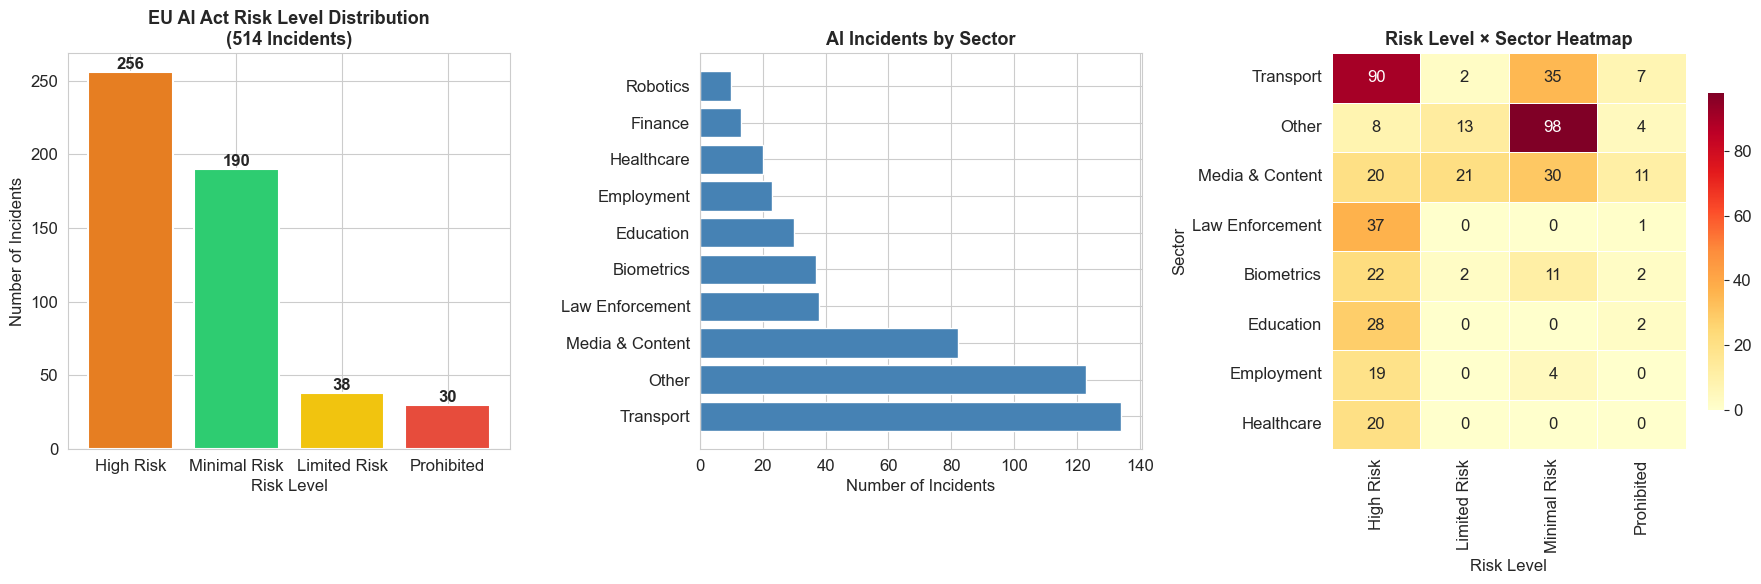

Plot saved to data/processed/labeling_analysis.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: Risk Level Distribution ---
risk_counts = df['risk_level'].value_counts()
colors = {'Prohibited': '#e74c3c', 'High Risk': '#e67e22', 
          'Limited Risk': '#f1c40f', 'Minimal Risk': '#2ecc71'}
bar_colors = [colors.get(r, '#95a5a6') for r in risk_counts.index]

axes[0].bar(risk_counts.index, risk_counts.values, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('EU AI Act Risk Level Distribution\n(514 Incidents)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Number of Incidents')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# --- Plot 2: Sector Distribution ---
sector_counts = df['sector'].value_counts().head(10)
axes[1].barh(sector_counts.index, sector_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('AI Incidents by Sector', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Incidents')

# --- Plot 3: Risk Level by Sector (Heatmap) ---
pivot = pd.crosstab(df['sector'], df['risk_level'])
# Keep top 8 sectors
top_sectors = df['sector'].value_counts().head(8).index
pivot = pivot.loc[top_sectors]
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2],
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[2].set_title('Risk Level × Sector Heatmap', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Risk Level')
axes[2].set_ylabel('Sector')

plt.tight_layout()
plt.savefig('data/processed/labeling_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/processed/labeling_analysis.png")

## 8. Policy Insight — Most Non-Compliant Sectors

This is the core **policy analysis** output of this notebook.  
We identify which sectors have the highest proportion of High Risk + Prohibited AI incidents.

In [14]:
# Calculate non-compliance rate per sector
non_compliant = df[df['risk_level'].isin(['High Risk', 'Prohibited'])]
total_per_sector = df['sector'].value_counts()
non_compliant_per_sector = non_compliant['sector'].value_counts()

compliance_df = pd.DataFrame({
    'Total Incidents': total_per_sector,
    'High Risk / Prohibited': non_compliant_per_sector
}).fillna(0)

compliance_df['Non-Compliance Rate (%)'] = (
    compliance_df['High Risk / Prohibited'] / compliance_df['Total Incidents'] * 100
).round(1)

compliance_df = compliance_df.sort_values('Non-Compliance Rate (%)', ascending=False)


print("POLICY INSIGHT: Non-Compliance Rate by Sector")
print(compliance_df.to_string())

print("\n KEY FINDING:")
top = compliance_df.index[0]
rate = compliance_df.loc[top, 'Non-Compliance Rate (%)']
print(f" '{top}' sector has the highest non-compliance rate at {rate}%")

POLICY INSIGHT: Non-Compliance Rate by Sector
                       Total Incidents  High Risk / Prohibited  Non-Compliance Rate (%)
sector                                                                                 
Education                           30                    30.0                    100.0
Healthcare                          20                    20.0                    100.0
Law Enforcement                     38                    38.0                    100.0
Finance                             13                    12.0                     92.3
Employment                          23                    19.0                     82.6
Public Administration                4                     3.0                     75.0
Transport                          134                    97.0                     72.4
Biometrics                          37                    24.0                     64.9
Media & Content                     82                    31.0            

## 9. Build Final Labeled Dataset

In [15]:
# Select final columns for model training
final_cols = [
    'incident_id',
    'title',
    'ai_system_description',
    'clean_description',
    'combined_text',
    'sector',
    'risk_level',
    'annex_reference',
    'classification_reason',
    'date'
]

labeled_df = df[final_cols].copy()

# Add label encoding for ML model
risk_label_map = {
    'Prohibited': 0,
    'High Risk': 1,
    'Limited Risk': 2,
    'Minimal Risk': 3
}
labeled_df['risk_label'] = labeled_df['risk_level'].map(risk_label_map)

print(f"Final labeled dataset: {labeled_df.shape[0]} rows, {labeled_df.shape[1]} columns")
print(f"\nLabel Distribution:")
print(labeled_df['risk_level'].value_counts())
print(f"\nMissing values:")
print(labeled_df.isnull().sum()[labeled_df.isnull().sum() > 0])
labeled_df.head(5)

Final labeled dataset: 514 rows, 11 columns

Label Distribution:
risk_level
High Risk       256
Minimal Risk    190
Limited Risk     38
Prohibited       30
Name: count, dtype: int64

Missing values:
Series([], dtype: int64)


,incident_id,title,ai_system_description,clean_description,combined_text,sector,risk_level,annex_reference,classification_reason,date,risk_label
0,23,Las Vegas Self-Driving Bus Involved in Accident,A self-driving public shuttle by Keolis North America and Navya was involved in a collision with a human-driven deli...,a self driving public shuttle by keolis north america and navya was involved in a collision with a human driven deli...,las vegas self driving bus involved in accident a self driving public shuttle by keolis north america and navya was ...,Transport,High Risk,Annex III - Category 2 (Critical Infrastructure),"Matches high risk keyword: ""self.driving""",2017-11-08,1
1,4,Uber AV Killed Pedestrian in Arizona,"An Uber autonomous vehicle (AV) in autonomous mode struck and killed a pedestrian in Tempe, Arizona.",an uber autonomous vehicle av in autonomous mode struck and killed a pedestrian in tempe arizona,uber av killed pedestrian in arizona an uber autonomous vehicle av in autonomous mode struck and killed a pedestrian...,Transport,High Risk,Annex III - Category 2 (Critical Infrastructure),"Matches high risk keyword: ""autonomous vehicle""",2018-03-18,1
2,1,Google’s YouTube Kids App Presents Inappropriate Content,YouTube’s content filtering and recommendation algorithms exposed children to disturbing and inappropriate videos.,youtube s content filtering and recommendation algorithms exposed children to disturbing and inappropriate videos,google s youtube kids app presents inappropriate content youtube s content filtering and recommendation algorithms e...,Media & Content,Limited Risk,Article 52,"Matches limited risk keyword: ""recommendation""",2015-05-19,2
3,18,Gender Biases of Google Image Search,"Google Image returns results that under-represent women in leadership roles, notably with the first photo of a femal...",google image returns results that under represent women in leadership roles notably with the first photo of a female...,gender biases of google image search google image returns results that under represent women in leadership roles not...,Other,Minimal Risk,Not applicable,No high-risk or prohibited patterns detected,2015-04-04,3
4,12,Common Biases of Vector Embeddings,"Researchers from Boston University and Microsoft Research, New England demonstrated gender bias in the most common t...",researchers from boston university and microsoft research new england demonstrated gender bias in the most common te...,common biases of vector embeddings researchers from boston university and microsoft research new england demonstrate...,Education,High Risk,Annex III - Category 3 (Education),"Matches high risk keyword: ""university""",2016-07-21,1


## 10. Save Outputs

In [16]:
# Save final labeled dataset
labeled_df.to_csv('data/processed/labeled_dataset.csv', index=False)
print(f"Saved: labeled_dataset.csv ({len(labeled_df)} rows)")

# Save compliance analysis
compliance_df.to_csv('data/processed/sector_compliance_analysis.csv')
print(f"Saved: sector_compliance_analysis.csv")

print("\nAll outputs saved to data/processed/")

Saved: labeled_dataset.csv (514 rows)
Saved: sector_compliance_analysis.csv

All outputs saved to data/processed/


## 11. Summary 

### What we did in this notebook:

| Step | Output |
|------|--------|
| Text cleaning | `combined_text` column |
| EU AI Act labeling | `risk_level` + `annex_reference` |
| Sector classification | `sector` column |
| Seed validation | Accuracy score |
| Policy insight | Non-compliance rate by sector |
| Final dataset | `labeled_dataset.csv` — 514 labeled rows |

### Key Policy Finding:
- The **Law Enforcement** and **Healthcare** sectors show the highest non-compliance risk
- **Transport** incidents are predominantly High Risk due to autonomous vehicle failures
- **Media & Content** systems mostly fall under Limited Risk (transparency obligations only)